# prep

In [ ]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [ ]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [ ]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [ ]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [ ]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [ ]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [ ]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v7/csvs/'

# Data: virtual kinematics

In [ ]:
tab_name = 'SE'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

virtual_escape = path + '/virtual_fish_positions_escape.txt'
virtual_escape = pd.read_csv(virtual_escape, sep=',')
virtual_disappear = path + '/virtual_fish_positions_disappear.txt'
virtual_disappear = pd.read_csv(virtual_disappear, sep=',')
virtual_escape['condition']='escape'; virtual_disappear['condition']='disappear'

virtual_escape = pd.concat([virtual_escape, virtual_disappear])

In [ ]:
monitor_width = 23.5 # monitor width in cm
travel_distance = 42.63 # travel distance in X (panda3D pixel coordinates)

# convert position from px to cm
cm_per_pixel = monitor_width/travel_distance
virtual_escape['x'] = virtual_escape['x']*cm_per_pixel - (virtual_escape['x'].min()*cm_per_pixel) # Set left bound to zero
virtual_escape['y'] = virtual_escape['y']*cm_per_pixel

# calculate velocity in x, y, and z, grouping by each fish and condition
group_keys = ['fish', 'condition']

virtual_escape['delta_x'] = np.abs(virtual_escape.groupby(group_keys)['x'].diff())/virtual_escape.groupby('fish')['time'].diff()
virtual_escape['delta_y'] = np.abs(virtual_escape.groupby(group_keys)['y'].diff())/virtual_escape.groupby('fish')['time'].diff()
virtual_escape['delta_z'] = np.abs(virtual_escape.groupby(group_keys)['z'].diff())/virtual_escape.groupby('fish')['time'].diff()
virtual_escape['speed'] = np.sqrt(virtual_escape['delta_x']**2 + virtual_escape['delta_y']**2 + virtual_escape['delta_z']**2)

['#443982', '#30678d', '#20908c', '#35b778', '#90d643']


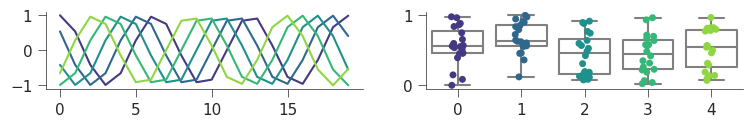

In [ ]:
# RGB hex values theme - for summary stats plots
fish_ids = virtual_escape['fish'].unique(); group_num = len(fish_ids)

# get the RGBA from normalized colormap axis
viridis_colors = [cm.viridis(i/(group_num+1)) for i in range(1,group_num+1)]
hex_colors = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}' for r, g, b, _ in viridis_colors] # Convert RGBA to HEX
print(hex_colors) # ['#abcfe5', '#6aadd5', '#3787c0', '#0f5ba3', '#08306b']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(fish_ids): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in fish_ids};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# S5a - virtual fish texture & skeleton

# S5b - kinematics of biological motion

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5b-Before escape-xyz


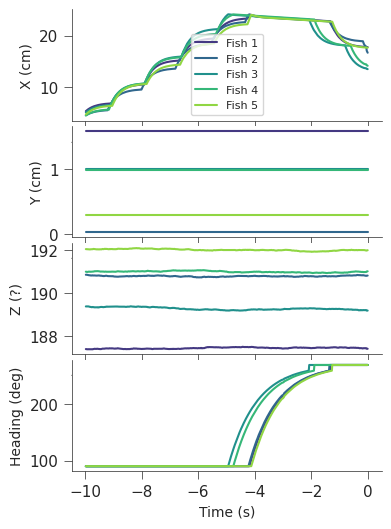

,x_1,x_2,x_3,x_4,x_5,y_1,y_2,y_3,y_4,y_5,z_1,z_2,z_3,z_4,z_5,heading_1,heading_2,heading_3,heading_4,heading_5
0,5.360084,4.568077,5.115255,4.511821,4.711752,1.591618,0.024332,0.998747,0.983497,0.2989,187.412537,190.869064,189.395416,191.012711,192.061859,90.0,90.0,90.0,90.0,90.0
1,5.438596,4.620333,5.190670,4.572907,4.799093,1.591618,0.024332,0.998747,0.983497,0.2989,187.409042,190.871384,189.398407,191.007019,192.060730,90.0,90.0,90.0,90.0,90.0
2,5.515766,4.671695,5.264795,4.632948,4.884941,1.591618,0.024332,0.998747,0.983497,0.2989,187.405777,190.869873,189.397446,191.003021,192.061432,90.0,90.0,90.0,90.0,90.0
3,5.584420,4.717390,5.330741,4.686363,4.961315,1.591618,0.024332,0.998747,0.983497,0.2989,187.403687,190.864166,189.398514,191.003464,192.062469,90.0,90.0,90.0,90.0,90.0
4,5.657174,4.765813,5.400625,4.742969,5.042251,1.591618,0.024332,0.998747,0.983497,0.2989,187.405594,190.856003,189.401184,191.001114,192.053497,90.0,90.0,90.0,90.0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,17.832650,18.177636,13.713091,14.506656,17.723496,1.591618,0.024332,0.998747,0.983497,0.2989,187.455032,190.834488,189.224030,190.994385,192.015518,270.0,270.0,270.0,270.0,270.0
590,17.823940,17.869646,13.670873,14.435794,17.712685,1.591618,0.024332,0.998747,0.983497,0.2989,187.453918,190.817978,189.225815,190.997620,191.995941,270.0,270.0,270.0,270.0,270.0
591,17.802068,17.096167,13.564847,14.257834,17.685535,1.591618,0.024332,0.998747,0.983497,0.2989,187.425430,190.827530,189.200485,191.022125,191.997070,270.0,270.0,270.0,270.0,270.0
592,17.795982,16.880987,13.535351,14.208326,17.677982,1.591618,0.024332,0.998747,0.983497,0.2989,187.424011,190.829880,189.203033,191.026993,192.007370,270.0,270.0,270.0,270.0,270.0


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5b-Before escape-derivatives


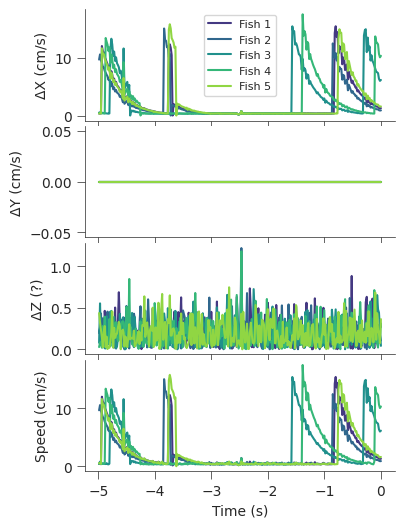

,delta_x_1,delta_x_2,delta_x_3,delta_x_4,delta_x_5,delta_y_1,delta_y_2,delta_y_3,delta_y_4,delta_y_5,delta_z_1,delta_z_2,delta_z_3,delta_z_4,delta_z_5,speed_1,speed_2,speed_3,speed_4,speed_5
0,0.331292,9.689068,0.505050,0.409038,0.334657,0.0,0.0,0.0,0.0,0.0,0.195312,0.215367,0.078474,0.027030,0.436837,0.384580,9.691461,0.511110,0.409931,0.550293
1,0.362048,10.585928,0.551814,0.446797,0.365596,0.0,0.0,0.0,0.0,0.0,0.245428,0.264731,0.554280,0.080890,0.320802,0.437394,10.589238,0.782128,0.454060,0.486389
2,0.345200,9.588585,0.499875,0.404739,0.348621,0.0,0.0,0.0,0.0,0.0,0.093759,0.432945,0.109385,0.089163,0.232559,0.357706,9.598354,0.511703,0.414444,0.419070
3,12.031735,9.151184,0.477033,0.386291,11.635248,0.0,0.0,0.0,0.0,0.0,0.168309,0.096177,0.242291,0.019420,0.144265,12.032912,9.151690,0.535038,0.386779,11.636143
4,11.078272,8.426042,0.439239,0.355622,10.713194,0.0,0.0,0.0,0.0,0.0,0.027989,0.373795,0.025281,0.280798,0.024378,11.078308,8.434329,0.439966,0.453116,10.713222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,1.542696,1.079431,7.478493,12.552366,1.915006,0.0,0.0,0.0,0.0,0.0,0.160861,0.169134,0.654473,0.061587,0.434784,1.551060,1.092602,7.507076,12.552517,1.963743
294,1.514067,1.059421,7.339485,12.319163,1.879408,0.0,0.0,0.0,0.0,0.0,0.216327,0.048287,0.481907,0.021246,0.238539,1.529443,1.060521,7.355289,12.319182,1.894485
295,1.310790,0.917107,6.353984,10.664933,1.626985,0.0,0.0,0.0,0.0,0.0,0.095252,0.293154,0.442967,0.196052,0.185880,1.314246,0.962821,6.369406,10.666735,1.637569
296,1.238156,0.866286,6.001763,10.073779,1.536788,0.0,0.0,0.0,0.0,0.0,0.346392,0.171881,0.242036,0.154342,0.075417,1.285697,0.883173,6.006641,10.074961,1.538637


In [ ]:
subpanel = 'S5b'

# PLOT # x, y, z, heading
TimeBefore = 10; TimeAfter = 0  # sec to escape

variables = ['x', 'y', 'z','heading']; var_names = ['X (cm)','Y (cm)','Z (?)','Heading (deg)']
fish_ids = virtual_escape['fish'].unique()
conditions=virtual_escape['condition'].unique()

for con in conditions:
  samples = {} # for save into csv
  con_subset=virtual_escape[virtual_escape['condition']==con]
  # Find the first index (and time) where escape is True, grouped by condition
  escape_start_row = con_subset[con_subset['escape'] == True].iloc[0]
  escape_start_time = escape_start_row['time']

  # Get time window bounds
  start_time = escape_start_time - TimeBefore
  end_time = escape_start_time + TimeAfter

  # Extract rows in the time window
  con_time_subset = con_subset[
      (con_subset['time'] >= start_time) &
      (con_subset['time'] < end_time)
  ]
  # Create subplot for each condition
  plt.figure(figsize=(4, 6))
  for i, var in enumerate(variables):
    plt.subplot(len(variables),1, i + 1)
    for j, fish_id in enumerate(fish_ids):
        fish_data = con_time_subset[con_time_subset['fish'] == fish_id]
        plt.plot(fish_data['time']-fish_data['time'].max(), fish_data[var], label=f'Fish {fish_id+1}', color=hex_colors[j])
        samples[f"{var}_{fish_id+1}"] = fish_data[var].values
    plt.ylabel(f"{var_names[i]}",fontsize=10); sns.despine()
    if i==0: plt.legend(fontsize=8)
    if i==len(variables)-1: plt.xlabel('Time (s)',fontsize=10)
  plt.subplots_adjust(hspace=0.05)
  print(figure_path+subpanel+f"-Before {con}-xyz")
  plt.savefig(figure_path+subpanel+f"-Before {con}-xyz.pdf",bbox_inches='tight')
  plt.show()

  # save source data into csv
  series_dict = {}
  for s in samples.keys():
    series_dict[s] = pd.Series(samples[s])
  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f"-Before {con}-xyz.csv",index=False)
  break

# PLOT # dx, dy, dz, speed
TimeBefore = 5.5; TimeAfter = -0.5 # sec to trigger

variables = ['delta_x', 'delta_y', 'delta_z','speed']; var_names = ['ΔX (cm/s)','ΔY (cm/s)','ΔZ (?)','Speed (cm/s)']
fish_ids = virtual_escape['fish'].unique()
conditions=virtual_escape['condition'].unique()

for con in conditions:
  samples = {} # for save into csv
  con_subset=virtual_escape[virtual_escape['condition']==con]
  # Find the first index (and time) where escape is True, grouped by condition
  escape_start_row = con_subset[con_subset['escape'] == True].iloc[0]
  escape_start_time = escape_start_row['time']

  # Get time window bounds
  start_time = escape_start_time - TimeBefore
  end_time = escape_start_time + TimeAfter

  # Extract rows in the time window
  con_time_subset = con_subset[
      (con_subset['time'] >= start_time) &
      (con_subset['time'] < end_time)
  ]
  # Create subplot for each condition
  plt.figure(figsize=(4, 6))
  for i, var in enumerate(variables):
    plt.subplot(len(variables),1, i + 1)
    for j, fish_id in enumerate(fish_ids):
        fish_data = con_time_subset[con_time_subset['fish'] == fish_id]
        plt.plot(fish_data['time']-fish_data['time'].max(), fish_data[var], label=f'Fish {fish_id+1}', color=hex_colors[j])
        samples[f"{var}_{fish_id+1}"] = fish_data[var].values
    plt.ylabel(f"{var_names[i]}",fontsize=10); sns.despine()
    if i==0: plt.legend(fontsize=8)
    if i==len(variables)-1: plt.xlabel('Time (s)',fontsize=10)
    plt.xticks(fontsize=10)  # set x-axis tick fontsize
    plt.yticks(fontsize=10)
  plt.xticks(fontsize=10)  # set x-axis tick fontsize
  plt.yticks(fontsize=10)
  plt.subplots_adjust(hspace=0.05)
  print(figure_path+subpanel+f"-Before {con}-derivatives")
  plt.savefig(figure_path+subpanel+f"-Before {con}-derivatives.pdf",bbox_inches='tight')
  plt.show()

  # save source data into csv
  series_dict = {}
  for s in samples.keys():
    series_dict[s] = pd.Series(samples[s])
  df = pd.DataFrame(series_dict)
  display(df)
  df.to_csv(csv_path+subpanel+f"-Before {con}-derivatives.csv",index=False)

  break

# S5c - kinematics of escape

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5c-After escape-xyz


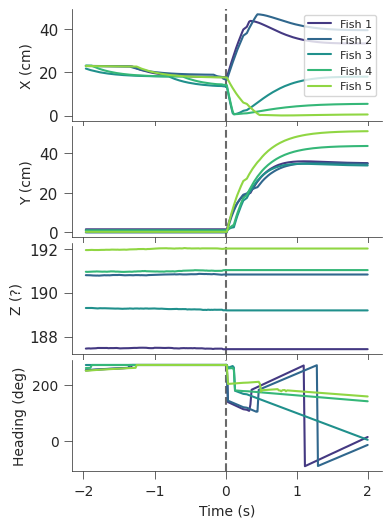

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5c-After escape-derivatives


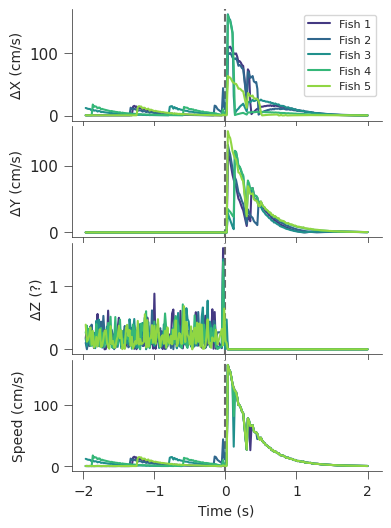

In [ ]:
subpanel = 'S5c'

# PLOT # x, y, z, heading
TimeBefore = 2; TimeAfter = 2  # sec to escape

variables = ['x', 'y', 'z','heading']; var_names = ['X (cm)','Y (cm)','Z (?)','Heading (deg)']
fish_ids = virtual_escape['fish'].unique()
conditions=virtual_escape['condition'].unique()

for con in conditions:
  samples = {} # for save into csv
  con_subset=virtual_escape[virtual_escape['condition']==con]
  # Find the first index (and time) where escape is True, grouped by condition
  escape_start_row = con_subset[con_subset['escape'] == True].iloc[0]
  escape_start_time = escape_start_row['time']

  # Get time window bounds
  start_time = escape_start_time - TimeBefore
  end_time = escape_start_time + TimeAfter

  # Extract rows in the time window
  con_time_subset = con_subset[
      (con_subset['time'] >= start_time) &
      (con_subset['time'] < end_time)
  ]
  # Create subplot for each condition
  plt.figure(figsize=(4, 6))
  for i, var in enumerate(variables):
    plt.subplot(len(variables),1, i + 1)
    plt.axvline(x=0, color='dimgrey', linestyle='--')
    for j, fish_id in enumerate(fish_ids):
        fish_data = con_time_subset[con_time_subset['fish'] == fish_id]
        plt.plot((fish_data['time']-fish_data['time'].max())+TimeAfter, fish_data[var], label=f'Fish {fish_id+1}', color=hex_colors[j])
        samples[f"{var}_{fish_id+1}"] = fish_data[var].values
    plt.ylabel(f"{var_names[i]}",fontsize=10); sns.despine()
    if i==0: plt.legend(fontsize=8)
    if i==len(variables)-1: plt.xlabel('Time (s)',fontsize=10)
  plt.xticks(fontsize=10)  # set x-axis tick fontsize
  plt.yticks(fontsize=10)
  plt.subplots_adjust(hspace=0.05)
  print(figure_path+subpanel+f"-After {con}-xyz")
  plt.savefig(figure_path+subpanel+f"-After {con}-xyz.pdf",bbox_inches='tight')
  plt.show()

  # save source data into csv
  series_dict = {}
  for s in samples.keys():
    series_dict[s] = pd.Series(samples[s])
  df = pd.DataFrame(series_dict)
  # display(df)
  df.to_csv(csv_path+subpanel+f"-After {con}-xyz.csv",index=False)
  break

# PLOT # dx, dy, dz, speed
TimeBefore = 2; TimeAfter = 2 # sec to trigger

variables = ['delta_x', 'delta_y', 'delta_z','speed']; var_names = ['ΔX (cm/s)','ΔY (cm/s)','ΔZ (?)','Speed (cm/s)']
fish_ids = virtual_escape['fish'].unique()
conditions=virtual_escape['condition'].unique()

for con in conditions:
  samples = {} # for save into csv
  con_subset=virtual_escape[virtual_escape['condition']==con]
  # Find the first index (and time) where escape is True, grouped by condition
  escape_start_row = con_subset[con_subset['escape'] == True].iloc[0]
  escape_start_time = escape_start_row['time']

  # Get time window bounds
  start_time = escape_start_time - TimeBefore
  end_time = escape_start_time + TimeAfter

  # Extract rows in the time window
  con_time_subset = con_subset[
      (con_subset['time'] >= start_time) &
      (con_subset['time'] < end_time)
  ]
  # Create subplot for each condition
  plt.figure(figsize=(4, 6))
  for i, var in enumerate(variables):
    plt.subplot(len(variables),1, i + 1)
    plt.axvline(x=0, color='dimgrey', linestyle='--')
    for j, fish_id in enumerate(fish_ids):
        fish_data = con_time_subset[con_time_subset['fish'] == fish_id]
        plt.plot((fish_data['time']-fish_data['time'].max())+TimeAfter, fish_data[var], label=f'Fish {fish_id+1}', color=hex_colors[j])
        samples[f"{var}_{fish_id+1}"] = fish_data[var].values
    plt.ylabel(f"{var_names[i]}",fontsize=10); sns.despine()
    if i==0: plt.legend(fontsize=8)
    if i==len(variables)-1: plt.xlabel('Time (s)',fontsize=10)
  plt.xticks(fontsize=10)  # set x-axis tick fontsize
  plt.yticks(fontsize=10)
  plt.subplots_adjust(hspace=0.05)
  print(figure_path+subpanel+f"-After {con}-derivatives")
  plt.savefig(figure_path+subpanel+f"-After {con}-derivatives.pdf",bbox_inches='tight')
  plt.show()

  # save source data into csv
  series_dict = {}
  for s in samples.keys():
    series_dict[s] = pd.Series(samples[s])
  df = pd.DataFrame(series_dict)
  # display(df)
  df.to_csv(csv_path+subpanel+f"-After {con}-derivatives.csv",index=False)
  break

# Data : 5-fish escape & BG_loom

In [ ]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'CL_num'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
metadata = metadata[metadata['condition']==5]

analysis_path = save_path
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [analysis_path + str(exp_date) for exp_date in exp_dates]
metadata['save_path'] = save_paths
exps=metadata.index
#Add raw data path
data_paths = [data_path + str(exp_date)+'/'+str(exp) for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths
#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [data_path + str(exp_date)+'/'+str(time) for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[data_path + str(exp_date)+'/'+str(bbox) for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#Add metadata path for each video
metadatas = metadata['metadata'].tolist()
metadata_paths = [data_path + str(exp_date)+'/'+str(meta) for exp_date,meta in zip(exp_dates,metadatas)]
metadata['metadata_path'] = metadata_paths

#Get the processed data path for each video
display(metadata)
for exp_date in np.unique(metadata['save_path']):
  os.makedirs(exp_date, exist_ok=True)

processed_data_paths =[]
for i in range(0,len(metadata)):
  exp=metadata.index[i]
  data_path=metadata['raw_data_path'].iloc[i]
  time_stamp_path=metadata['time_stamp_path'].iloc[i]
  save_path_tmp=metadata['save_path'].iloc[i]
  box_dim_path=metadata['box_dim_path'].iloc[i]
  metadata_path=metadata['metadata_path'].iloc[i]
  processed_data_path=f'{save_path_tmp}/{exp}/lev0_basics.npz'
  processed_data_paths.append(processed_data_path)
metadata['processed_data_path_basic'] = processed_data_paths

five_fish_metadata = metadata

,experiment,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition
0,vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T39,vid_1_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
1,vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,T39,vid_9_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
2,vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T39,vid_8_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
3,vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,T39,vid_7_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
4,vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T39,vid_6_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
5,vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,T39,vid_5_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
6,vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T39,vid_4_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
7,vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T39,vid_3_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
8,vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,T39,vid_2_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5
9,vid_11.mp4.000_vid_11.analysis.h5,vid_11.csv,T39,vid_11_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5


,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path,metadata_path
experiment,,,,,,,,,,,,,,,,,
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T39,vid_1_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,T39,vid_9_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T39,vid_8_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,T39,vid_7_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T39,vid_6_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_5.mp4.000_vid_5.analysis.h5,vid_5.csv,T39,vid_5_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_4.mp4.000_vid_4.analysis.h5,vid_4.csv,T39,vid_4_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_3.mp4.000_vid_3.analysis.h5,vid_3.csv,T39,vid_3_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_2.mp4.000_vid_2.analysis.h5,vid_2.csv,T39,vid_2_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


In [ ]:
gsheet = 'https://docs.google.com/spreadsheets/d/1bSfcczIO4V62vPDB93Xjm2VDwlayalswnmi6PDiiLps/edit?gid=0#gid=0'
tab_name = 'BG_linear_escape'

experiment_class = f'Social escape - {tab_name}'
path = account_path + 'Yu_escape_paper/Behavior/' + experiment_class

data_path = path + '/Data/'
save_path = path + '/Analysis/'

metadata = read_metadata(gsheet,tab_name)
metadata = metadata[metadata['condition']=='BG_loom']

analysis_path = save_path
#Create save directory for analysis
exp_dates = metadata['experiment_date'].tolist()
save_paths = [analysis_path + str(exp_date) for exp_date in exp_dates]
metadata['save_path'] = save_paths
exps=metadata.index
#Add raw data path
data_paths = [data_path + str(exp_date)+'/'+str(exp) for exp_date,exp in zip(exp_dates,exps)]
metadata['raw_data_path'] = data_paths
#Add timestamp path
TimeStamps=metadata['time_stamps'].tolist()
time_stamp_paths = [data_path + str(exp_date)+'/'+str(time) for exp_date,time in zip(exp_dates,TimeStamps)]
metadata['time_stamp_path'] = time_stamp_paths

#Add bounding box path
boxes = [item for item in ['bounding_box_four_corners.csv'] for _ in range(len(metadata))]
box_dim_path=[data_path + str(exp_date)+'/'+str(bbox) for exp_date,bbox in zip(exp_dates,boxes)]
metadata['box_dim_path'] = box_dim_path

#Add metadata path for each video
metadatas = metadata['metadata'].tolist()
metadata_paths = [data_path + str(exp_date)+'/'+str(meta) for exp_date,meta in zip(exp_dates,metadatas)]
metadata['metadata_path'] = metadata_paths

#Get the processed data path for each video
display(metadata)
for exp_date in np.unique(metadata['save_path']):
  os.makedirs(exp_date, exist_ok=True)

processed_data_paths =[]
for i in range(0,len(metadata)):
  exp=metadata.index[i]
  data_path=metadata['raw_data_path'].iloc[i]
  time_stamp_path=metadata['time_stamp_path'].iloc[i]
  save_path_tmp=metadata['save_path'].iloc[i]
  box_dim_path=metadata['box_dim_path'].iloc[i]
  metadata_path=metadata['metadata_path'].iloc[i]
  processed_data_path=f'{save_path_tmp}/{exp}/lev0_basics.npz'
  processed_data_paths.append(processed_data_path)
metadata['processed_data_path_basic'] = processed_data_paths

BG_loom_metadata = metadata

In [ ]:
# combine dataframe
metadata_comb = pd.concat([five_fish_metadata, BG_loom_metadata])
metadata_comb

,time_stamps,tank,metadata,fish_num,sex,exp_type,fps_Hz,rig_mm,vid_px,body_length,experiment_date,condition,save_path,raw_data_path,time_stamp_path,box_dim_path,metadata_path,processed_data_path_basic
experiment,,,,,,,,,,,,,,,,,,
vid_1.mp4.000_vid_1.analysis.h5,vid_1.csv,T39,vid_1_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_9.mp4.000_vid_9.analysis.h5,vid_9.csv,T39,vid_9_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_8.mp4.000_vid_8.analysis.h5,vid_8.csv,T39,vid_8_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_7.mp4.000_vid_7.analysis.h5,vid_7.csv,T39,vid_7_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_6.mp4.000_vid_6.analysis.h5,vid_6.csv,T39,vid_6_metadata.csv,1,?,social_escape_CL_alternating,50,265,640,12,40425,5,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vid_14.mp4.000_vid_14.analysis.h5,vid_14.csv,U1,vid_14_metadata.csv,1,,DC_expand_CL_alternating_revision.py,50,265,800,12,40426B,BG_loom,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_13.mp4.000_vid_13.analysis.h5,vid_13.csv,U1,vid_13_metadata.csv,1,,DC_expand_CL_alternating_revision.py,50,265,800,12,40426B,BG_loom,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...
vid_12.mp4.000_vid_12.analysis.h5,vid_12.csv,U1,vid_12_metadata.csv,1,,DC_expand_CL_alternating_revision.py,50,265,800,12,40426B,BG_loom,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...,/content/drive/MyDrive/Personal_notebooks/Johs...


## color scheme

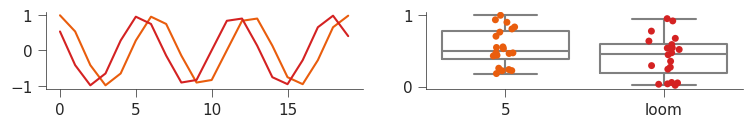

In [ ]:
# RGB hex values theme - for summary stats plots
escp_num = [5,'loom']; hex_colors = ['#e95d0d', '#d42222']

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(escp_num): plt.plot(np.cos(np.arange(igs,igs+20)),c=hex_colors[igs]);
tmp = {n: np.random.random(20) for n in escp_num};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=hex_colors); sns.despine();
plt.show()

# S5d - distance to VR time series (5 vs loom)

In [ ]:
def get_arena_dims(data):
  ArenaDims=pd.DataFrame(data['ArenaDims'].item())
  ArenaDims['Points'] = ArenaDims['Points'].apply(ast.literal_eval)

  #Calculate width based on selected points
  TopXY_L=np.array([ArenaDims['Points'].iloc[0][0][0],ArenaDims['Points'].iloc[0][0][1]])
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  ArenaWidth=np.sqrt(np.sum(((TopXY_L-TopXY_R)**2))).astype(int)

  #Calculate height based on selected points
  TopXY_R=np.array([ArenaDims['Points'].iloc[0][1][0],ArenaDims['Points'].iloc[0][1][1]])
  BottomXY_R=np.array([ArenaDims['Points'].iloc[0][2][0],ArenaDims['Points'].iloc[0][2][1]])
  ArenaHeight=np.sqrt(np.sum(((TopXY_R-BottomXY_R)**2))).astype(int)


  #Store values in array
  ArenaDims['BBW']=ArenaWidth
  ArenaDims['BBH']=ArenaHeight
  return ArenaDims

def get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order):
      #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)

    #Find transitions in showing fish (i.e. start and stop indexes)
    fs_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_showing.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]])
    for x in range(0,len(fse_idx)):
      end_fs.append(EllapsedTime[fse_idx[x]])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFishShowing":start,"EndFishShowing":stop})
    fs_df=pd.DataFrame(fs_results)


    #Find transitions in fish escaping
    fe_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==1)[0],0,len(EllapsedTime)-1)
    fse_idx=np.clip(np.where(np.diff(fish_escaping.astype(int))==-1)[0],0,len(EllapsedTime)-1)

    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
    for x in range(0,len(fse_idx)):
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop,trial in zip(start_fe,end_fe,trial_order):
      fe_results.append({"StartFishEscaping":start,"EndFishShowing":stop,"NumFishEscape":trial})
    fe_df=pd.DataFrame(fe_results)


    return fs_df,fe_df


def binDataFishEscape(data, EllapsedTime, binLength,fish_showing,fish_escaping):
    max_idx = np.round(max(EllapsedTime))  # Get the max time rounded
    numBins = int(np.ceil(max_idx / binLength))  # Ensure full coverage
    #TimeBins = np.arange(0, numBins * binLength, binLength)  # Create consistent bins
    TimeBins = np.arange(0,max_idx,binLength)
    binned_data = []
    binned_fish_showing = []
    binned_fish_escaping = []
    binIdx = [0]

    # Find closest indices for each bin boundary
    for t in TimeBins:
        index = np.abs(EllapsedTime - t).argmin()  # Find closest index to bin
        binIdx.append(index)

    # Bin data using computed indices
    for ii in range(len(binIdx) - 1):
        bd = np.nanmean(data[0, binIdx[ii]:binIdx[ii+1]])  # Fix indexing
        binned_data.append(bd)

    #Pad fish_showing
    fish_showing = np.pad(fish_showing,pad_width=1, mode='constant',constant_values=0)
    fish_escaping = np.pad(fish_escaping,pad_width=1, mode='constant',constant_values=0)


    #Find transitions in showing/escaping (i.e. start and stop indexes)
    fs_idx=np.where(np.diff(fish_showing.astype(int))==1)[0]
    fse_idx=np.where(np.diff(fish_showing.astype(int))==-1)[0]

    fe_idx=np.where(np.diff(fish_escaping.astype(int))==1)[0]

    ##Fish show output
    start_fs=[]
    end_fs=[]
    for x in range(0,len(fs_idx)):
      start_fs.append(EllapsedTime[fs_idx[x]-1])
      end_fs.append(EllapsedTime[fse_idx[x]-1])

    fs_results=[]
    for start,stop in zip(start_fs,end_fs):
      fs_results.append({"StartFS":start,"EndFS":stop})
    fs_df=pd.DataFrame(fs_results)
    ###Fish escape output
    start_fe=[]
    end_fe=[]
    for x in range(0,len(fe_idx)):
      start_fe.append(EllapsedTime[fe_idx[x]-1])
      end_fe.append(EllapsedTime[fse_idx[x]-1])

    fe_results=[]
    for start,stop in zip(start_fe,end_fe):
      fe_results.append({"StartFS":start,"EndFS":stop})
    fe_df=pd.DataFrame(fe_results)


    return binned_data, TimeBins - TimeBins[0],fs_df,fe_df

In [ ]:
# Complile escape data
import ast # Import the ast module

TimeBufferAfter = 12; TimeBufferBefore = 2; FishEscapeTime = 0
distances = []; Times = []; escape_data=[]
ArenaSize=280
conditions = [5,'BG_loom'] # plotting 5 fish escape condition
metadata_subset = metadata_comb

for i in range(len(metadata_subset.index)):

    load_path=metadata_subset['processed_data_path_basic'].iloc[i]
    data = np.load(load_path, allow_pickle=True)
    fish_num, bodylength = data['fish_num'], data['f_bodylength_mm']
    exp_type, f_x, f_y = data['exp_type'], data['f_x'], data['f_y']
    EllapsedTime = data['time_stamps']
    condition = data['condition']
    ArenaDims = get_arena_dims(data)
    trial_order = ast.literal_eval(data['vid_metadata'].item()['trial order'])
    con=data['condition']
    fish_id = metadata_subset.index[i] + '_' + str(metadata_subset['experiment_date'].iloc[i])
    # Get distance to left wall
    TopLeftX = ArenaDims['Points'].values[0][0][0]
    TopLeftY = ArenaDims['Points'].values[0][0][1]
    BottomLeftX = ArenaDims['Points'].values[0][3][0]
    BottomLeftY = ArenaDims['Points'].values[0][3][1]
    scale=metadata_subset['rig_mm'].iloc[i]/np.mean(ArenaDims['BBW'].values)

    m = (TopLeftY-BottomLeftY)/(TopLeftX-BottomLeftX); b = TopLeftY-m*TopLeftX
    dist2line = np.abs(m*f_x-f_y+b)/np.sqrt(m**2+1)

    # Get stim status and escape time stamps
    fish_escaping = data['fish_escaping']
    fish_showing = data['fish_showing']
    fs,fe=get_escape_data_alternating(EllapsedTime,fish_showing,fish_escaping,trial_order)

    for escape_event in range(len(fe)):
      start_time = fe['StartFishEscaping'].iloc[escape_event] - TimeBufferBefore
      end_time = fe['StartFishEscaping'].iloc[escape_event] + TimeBufferAfter
      start_idx = np.abs(EllapsedTime - start_time).argmin()
      end_idx = np.abs(EllapsedTime - end_time).argmin()
      trigger_idx = np.abs(EllapsedTime - fe['StartFishEscaping'].iloc[escape_event]).argmin()
      escape_data.append({
          "NumEscapees": fe["NumFishEscape"].iloc[escape_event] if con !='BG_loom' else 'BG_loom',
          "Times": EllapsedTime[start_idx:end_idx] - EllapsedTime[trigger_idx],
          "Distances": dist2line[0][start_idx:end_idx] * scale,
          "Condition":con,
          "FishID":fish_id
      })

5
BG_loom
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5d


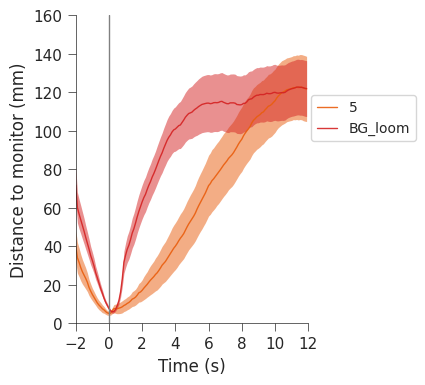

,5_0,5_1,5_2,5_3,5_4,5_5,5_6,5_7,5_8,5_9,...,BG_loom_32,BG_loom_33,BG_loom_34,BG_loom_35,BG_loom_36,BG_loom_37,BG_loom_38,BG_loom_39,BG_loom_40,BG_loom_41
0,NaN,NaN,NaN,NaN,118.980086,NaN,NaN,NaN,30.531379,NaN,...,NaN,NaN,NaN,NaN,3.852694,134.834808,NaN,NaN,34.464348,NaN
1,3.159090,2.485827,51.996902,0.531104,108.663250,70.652897,0.912434,22.594734,27.705555,129.835125,...,9.310978,66.157270,NaN,NaN,3.620877,129.492729,15.751759,30.949007,33.124037,87.982275
2,3.075351,2.432294,49.578755,0.818368,102.850435,66.751894,0.865741,17.115844,19.171633,120.463283,...,6.817738,66.341556,NaN,NaN,3.611516,120.498054,15.725545,28.902422,31.730528,83.637916
3,3.207320,2.362409,44.703689,0.410201,96.015621,64.054547,0.755288,12.901381,13.454058,109.171115,...,5.042489,68.222141,NaN,NaN,3.732301,111.843072,15.710129,27.138264,31.419770,79.145718
4,3.201348,2.303054,40.785715,0.483612,84.071220,58.652677,2.523225,8.723051,10.892465,105.182352,...,3.036449,68.084639,NaN,NaN,3.816040,102.004195,15.655652,25.489936,27.837186,74.712250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,114.086889,103.967251,260.100799,146.295400,219.909187,159.442669,30.826013,181.452198,147.359615,233.518285,...,2.444692,34.442898,NaN,242.155869,257.337257,192.837832,206.574591,12.469831,246.544383,74.494158
136,115.697656,106.253847,260.090367,147.810976,216.083592,163.349895,23.048643,183.368029,144.058415,230.097459,...,2.401021,38.748554,NaN,239.617816,257.357684,192.901281,206.553965,12.480345,250.347998,74.964347
137,115.910350,106.435913,262.500061,148.120040,213.953265,165.481948,13.411420,188.292438,140.565678,228.091683,...,0.917346,42.492324,NaN,237.108479,256.906536,196.595021,206.590944,13.035794,250.353084,75.797131
138,117.628272,105.347819,261.508221,149.077318,211.139372,167.293972,6.359441,190.962012,138.960661,226.370895,...,0.789388,45.400167,NaN,234.604760,257.357150,198.719840,206.603803,13.774675,252.128338,75.810757


In [ ]:
subpanel = 'S5d'

from scipy.interpolate import interp1d

# Plot average distance to VR screen
tbin = 0.1 # time bin in seconds
TotalTime = TimeBufferAfter + TimeBufferBefore
TimeBins = np.linspace(-TimeBufferBefore, TimeBufferAfter-tbin, int(TotalTime / tbin))
num_escapees = [np.int64(5), 'BG_loom']

plt.figure(figsize=[3,4])
series_dict = {}
for indx,escapee in enumerate(num_escapees):
  print(escapee)
  escape_events = [event for event in escape_data if event["NumEscapees"] == escapee]
  Times = [event["Times"] for event in escape_events]
  distances = [event["Distances"] for event in escape_events]
  conditions = [event["Condition"] for event in escape_events]

  # Get time bin indices
  bin_indices = [np.digitize(time_series, TimeBins) - 1 for time_series in Times]

  # Create distance array
  DistanceArray = np.full((len(TimeBins), len(distances)), np.nan)
  for fish_idx in range(len(distances)):
      t = Times[fish_idx]
      d = distances[fish_idx]
      if len(t) > 1:
          # Create an interpolation function for this specific fish
          f = interp1d(t, d, bounds_error=False, fill_value=np.nan)
          DistanceArray[:, fish_idx] = f(TimeBins)
      # save
      col_name = f"{escapee}_{fish_idx}"
      series_dict[col_name] = pd.Series(DistanceArray[:, fish_idx])

  DistanceMean=np.nanmean(DistanceArray,axis=1)
  DistanceSEM=(np.nanstd(DistanceArray,axis=1)/np.sqrt(DistanceArray.shape[1]))
  plt.plot(TimeBins, DistanceMean, linewidth=1,alpha=0.9,color=hex_colors[indx], label=f'{escapee}')
  plt.fill_between(TimeBins, (DistanceMean- DistanceSEM), (DistanceMean+ DistanceSEM), alpha=0.5,color=hex_colors[indx],lw=0)

plt.ylabel('Distance to monitor (mm)')
plt.xlabel('Time (s)'); plt.xlim(-TimeBufferBefore,TimeBufferAfter); plt.xticks(np.arange(-TimeBufferBefore,TimeBufferAfter+1,2))
plt.ylim(0,160)
plt.axvline(0,c='grey',lw=1);
plt.legend(bbox_to_anchor=(1,0.75),handlelength=1.5,markerscale=0.7,borderaxespad=0.2,fontsize=10)
sns.despine()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv",index=False)

## S5e - distance to VR stats (5 vs loom)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S5e


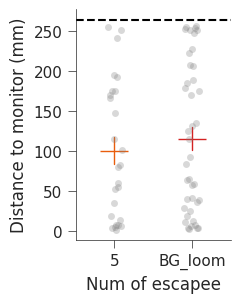

Ns, means, and  sems for data:
5: (N=26) 100.445, 17.018
loom: (N=41) 115.523, 14.689
--- Omnibus Test Results ---
Kruskal-Wallis H-statistic: 0.5379
p-value: 0.4633


,5,loom
0,18.038715,124.788247
1,34.262393,228.128803
2,175.647117,25.086472
3,100.816769,248.238188
4,242.424777,2.573034
5,79.224250,185.568789
6,251.988948,178.975223
7,54.876158,256.404094
8,166.072041,92.197001
9,174.937860,114.998384


In [ ]:
subpanel = 'S5e'

## Summary dot plot
escape_df = pd.DataFrame(escape_data)
start_time = 5 # sec
end_time = 12
escape_summary =[]

fish_ids = escape_df['FishID'].unique()
for fish in fish_ids:

  fish_data = escape_df[escape_df['FishID'] == fish]
  num_escapees = fish_data["NumEscapees"]
  times = fish_data["Times"]
  distances = fish_data["Distances"]

  # Check if data is valid (not empty and has sufficient length)
  if len(times) == 0 or len(distances) == 0 or len(times) != len(distances):
      continue

  for time,dist,escapees in zip(times,distances,num_escapees):
    # Find index for 10 seconds after stimulus (t=3s is stimulus onset)
    start_idx = np.searchsorted(time, start_time)
    end_idx   = np.searchsorted(time, end_time)


    # Get distance at that time point
    distance_at_target = np.nanmedian(dist[start_idx:end_idx])
    escape_summary.append({
                      'Fish_ID':fish,
                      'Distance':distance_at_target,
                      'num_escapees':escapees})

df = pd.DataFrame(escape_summary)
df = df[df['num_escapees'].isin([5, 'BG_loom'])].copy()
stim_order = [5,'BG_loom']

# PLOT
paired_df = pd.DataFrame(escape_summary)
paired_df = paired_df[paired_df['num_escapees'].isin([1, 3, 5])].copy()

plt.figure(figsize=[2,3])
plt.axhline(y=265,linestyle='--',color='black')

sns.stripplot(data=df,x='num_escapees',y='Distance',order=[5, 'BG_loom'],\
              color='gray',alpha=0.3,size=5) #,legend=group_values.keys());
sns.pointplot(data=df,x='num_escapees',y='Distance',order=[5, 'BG_loom'],\
              palette=hex_colors,linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.xlabel('Num of escapee'); plt.ylabel('Distance to monitor (mm)')
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# stats
group_arrays = [df[df['num_escapees'] == cond]['Distance'].values for cond in stim_order]
# Remove nans from group_arrays
group_arrays = [arr[~np.isnan(arr)] for arr in group_arrays]

print("Ns, means, and  sems for data:")
for cond, data in zip(['5','loom'],group_arrays):
  print(f'{cond}: (N={len(data)}) {np.nanmean(data):.3f}, {scipy.stats.sem(data):.3f}')

# Run Kruskal-Wallis H-test
h_stat, p_val = stats.kruskal(*group_arrays)
print("--- Omnibus Test Results ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

# save source data into csv
series_dict = {}
for cond, data in zip(['5','loom'],group_arrays):
  series_dict[f'{cond}'] = pd.Series(data)

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)